In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [3]:
# load excel file but use sheet1 only

df = pd.read_excel('main data.xlsx', sheet_name='Sheet1')
df.head()


,jnisAsnaf,TAHUN,DAERAH,jenisSkim,Nama,NoKP,tlahir,Umur,Jantina,kesihatan,...,Ibu Tunggal.1,Pesakit Dialisis (Percuma),Pesakit Dialisis (Berbayar),JumlahPerbelanjaan2,KiraanHK,StatusBaruPemutihan,StatusPermohonanBulanan,StatusDitamatkan,TMulaAgihan,TempohAgihan(Bulan)
0,MISKIN,2024,BL,AGIHAN KEWANGAN MISKIN BULANAN,CHE NAP BINTI IBRAHIM,510322025180,1951-03-22 00:00:00.000,74,P,SAKIT,...,1.0,False,False,240.0,-273.68,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-06-01 00:00:00.000,12
1,MISKIN,2024,BL,AGIHAN KEWANGAN MISKIN BULANAN,AWANG KECHIK BIN OSMAN,640703025497,1964-07-03 00:00:00.000,61,L,SIHAT(NORMAL),...,NaN,False,False,0.0,-393.88,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-04-11 00:00:00.000,12
2,MISKIN,2024,BL,AGIHAN KEWANGAN MISKIN BULANAN,AHMAD NASYAHRUDDIN BIN SAAD,860915265083,1986-09-15 00:00:00.000,39,L,SIHAT(NORMAL),...,NaN,False,False,0.0,-142.79,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-04-08 00:00:00.000,12
3,MISKIN,2024,PT,AGIHAN KEWANGAN MISKIN BULANAN,AMINAH BINTI HUSAIN,560729025380,1956-07-29 00:00:00.000,69,P,SIHAT(NORMAL),...,NaN,False,False,0.0,-133.68,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-04-07 00:00:00.000,12
4,MISKIN,2024,BL,AGIHAN KEWANGAN MISKIN BULANAN,MOHD KARIMI BIN KAMARUDIN,850924025541,1985-09-24 00:00:00.000,40,L,SIHAT(NORMAL),...,NaN,False,False,0.0,-255.59,PEMUTIHAN,LULUS AGIHAN BULANAN,BIASA,2025-04-05 00:00:00.000,12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9923 entries, 0 to 9922
Data columns (total 90 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   jnisAsnaf                                                              9923 non-null   object 
 1   TAHUN                                                                  9923 non-null   int64  
 2   DAERAH                                                                 9923 non-null   object 
 3   jenisSkim                                                              9923 non-null   object 
 4   Nama                                                                   9923 non-null   object 
 5   NoKP                                                                   9923 non-null   object 
 6   tlahir                                                                 7316 non-null   o

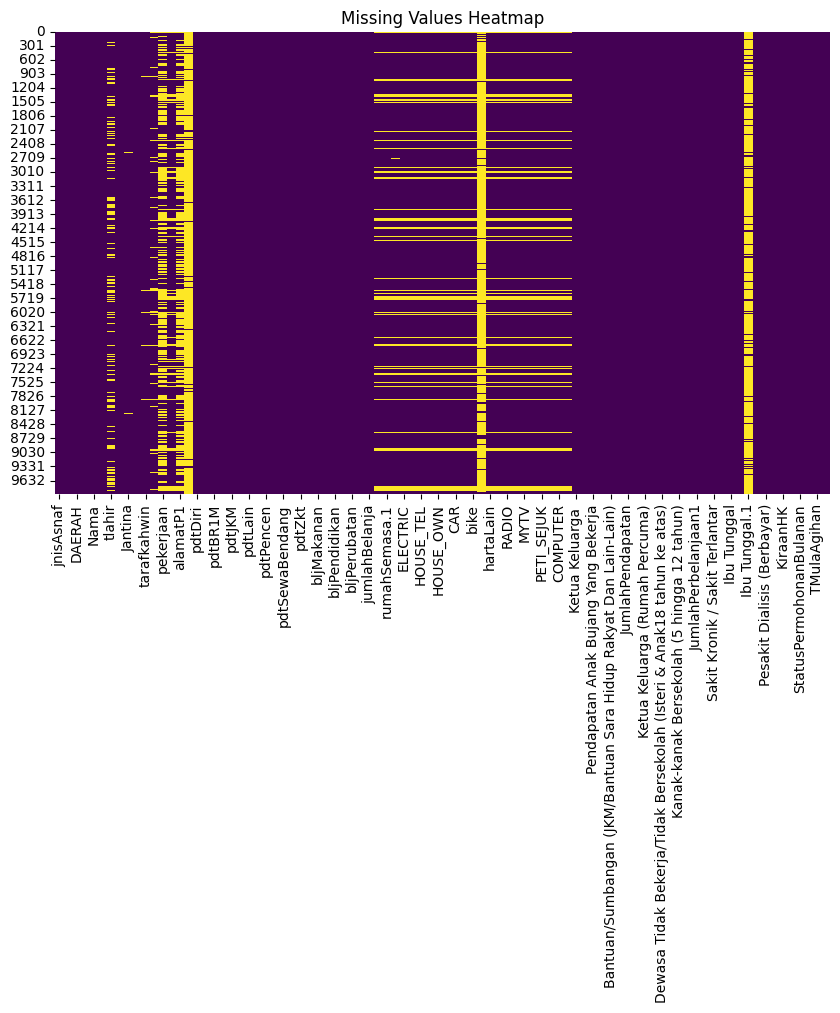

In [4]:
# data information

df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.nunique()
# check for outliers

#missing values

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()



Remaining missing values after handling:
jnisAsnaf                  0
TAHUN                      0
DAERAH                     0
jenisSkim                  0
Nama                       0
                          ..
StatusBaruPemutihan        0
StatusPermohonanBulanan    0
StatusDitamatkan           0
TMulaAgihan                0
TempohAgihan(Bulan)        0
Length: 90, dtype: int64


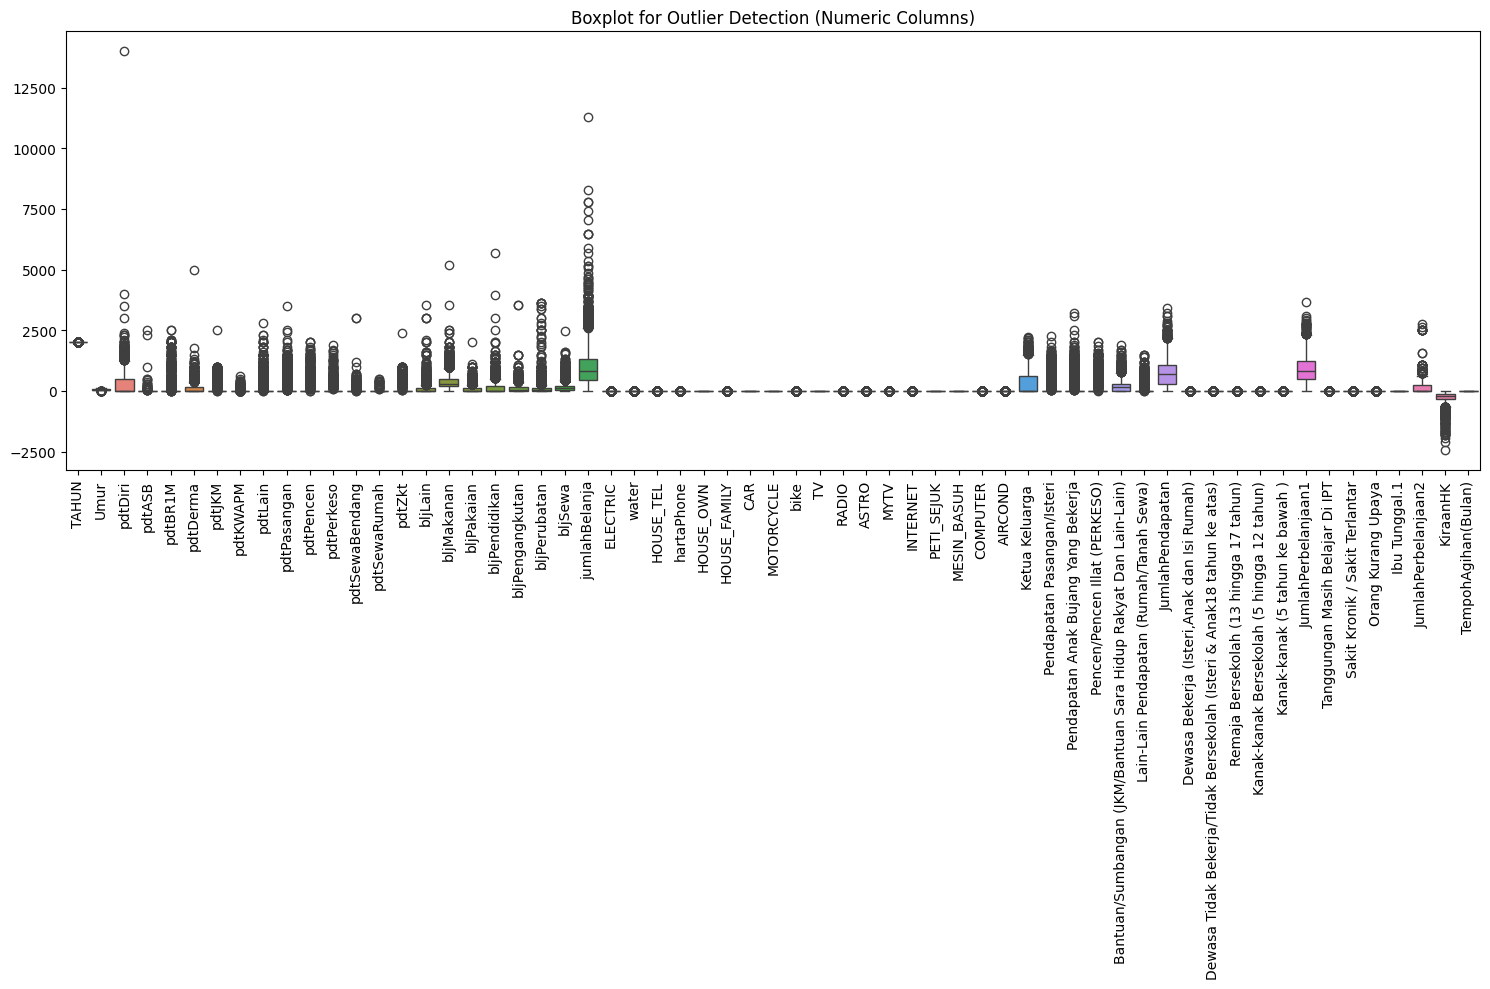

In [5]:
#handle missing values

# For numeric columns, fill with mean
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# For categorical/object columns, fill with mode
categorical_columns = df.select_dtypes(include=['object']).columns
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

print("Remaining missing values after handling:")
print(df.isnull().sum())

# check for outliers in numeric columns only
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numeric_columns])
plt.xticks(rotation=90)
plt.title('Boxplot for Outlier Detection (Numeric Columns)')
plt.tight_layout()
plt.show()

In [6]:
# Define poverty line threshold (based on Malaysian poverty line)
# You can adjust this value based on current Malaysian poverty line income
POVERTY_LINE = 2208  # RM per month (Malaysia's poverty line income 2022)

print(f"Poverty line threshold set to: RM {POVERTY_LINE} per month")

Poverty line threshold set to: RM 2208 per month


Basic Dataset Information:
Total number of records: 9923
Total number of features: 90

Feature Types Distribution:
float64    50
object     23
int64      11
bool        6
Name: count, dtype: int64


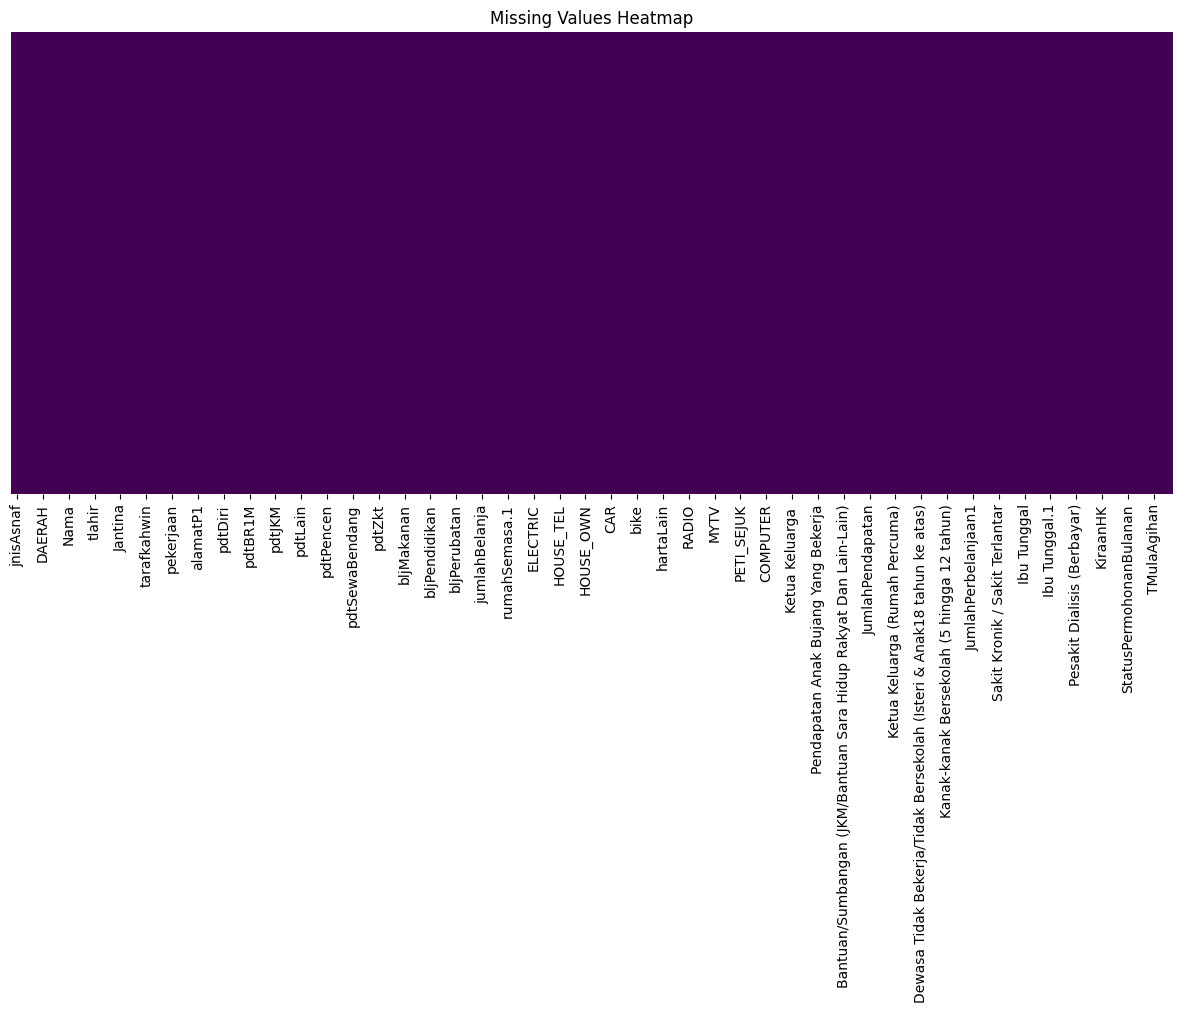

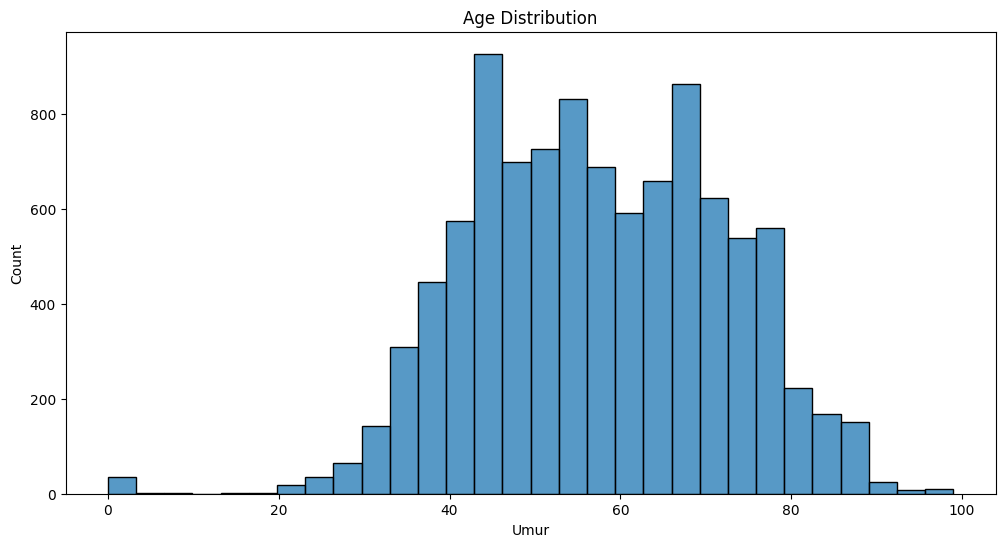

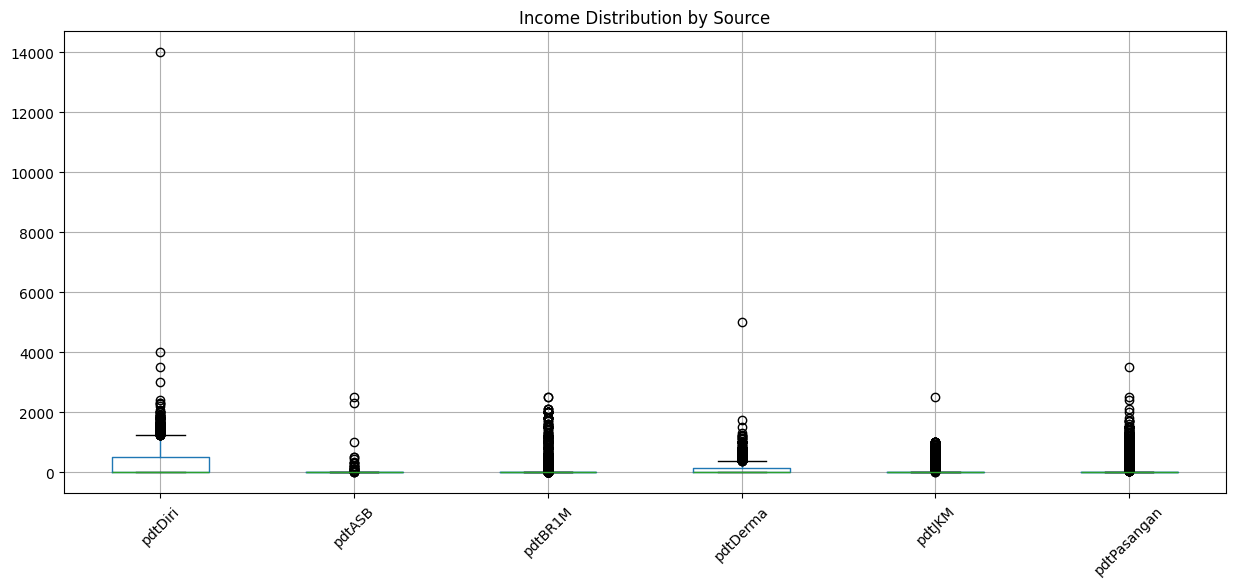

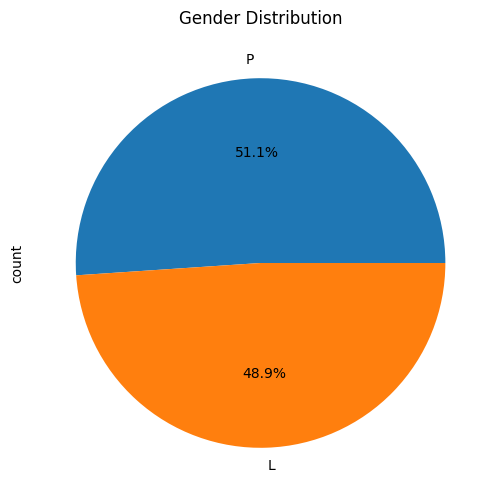

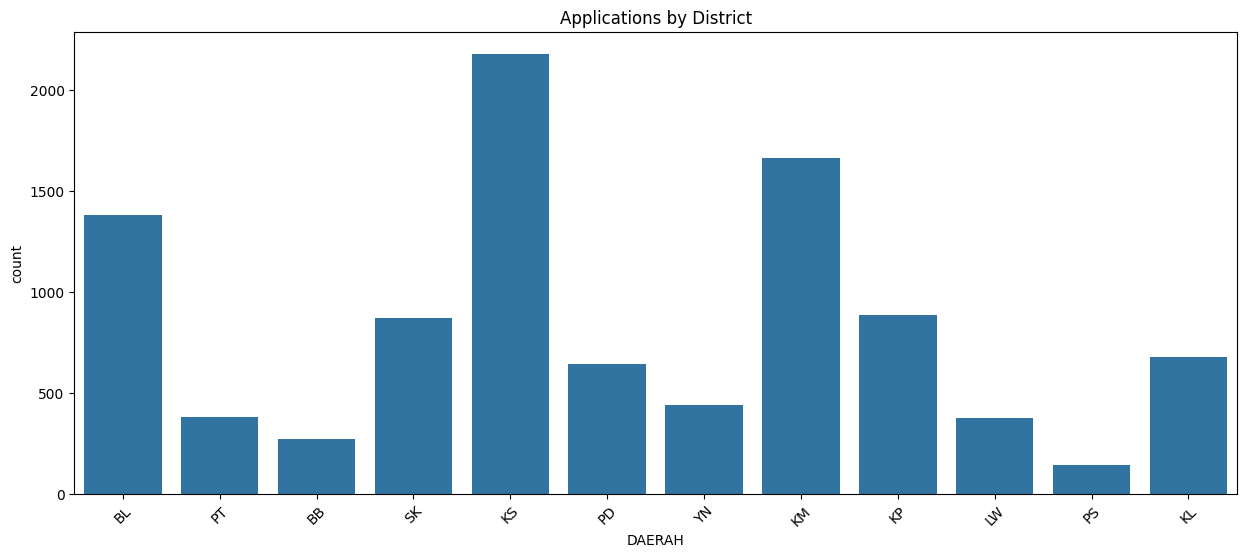

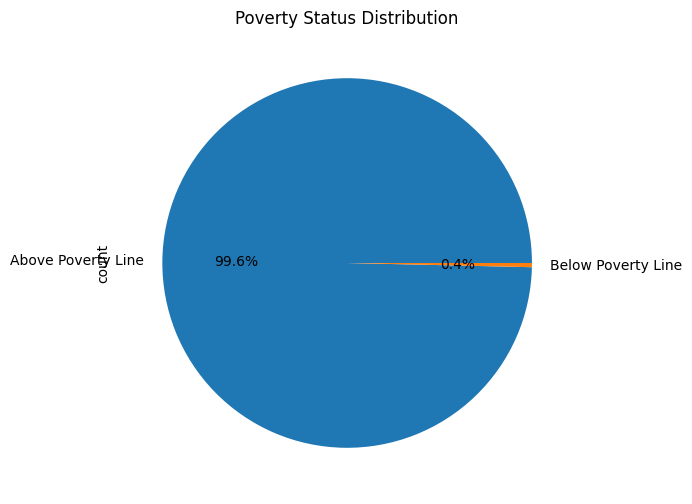

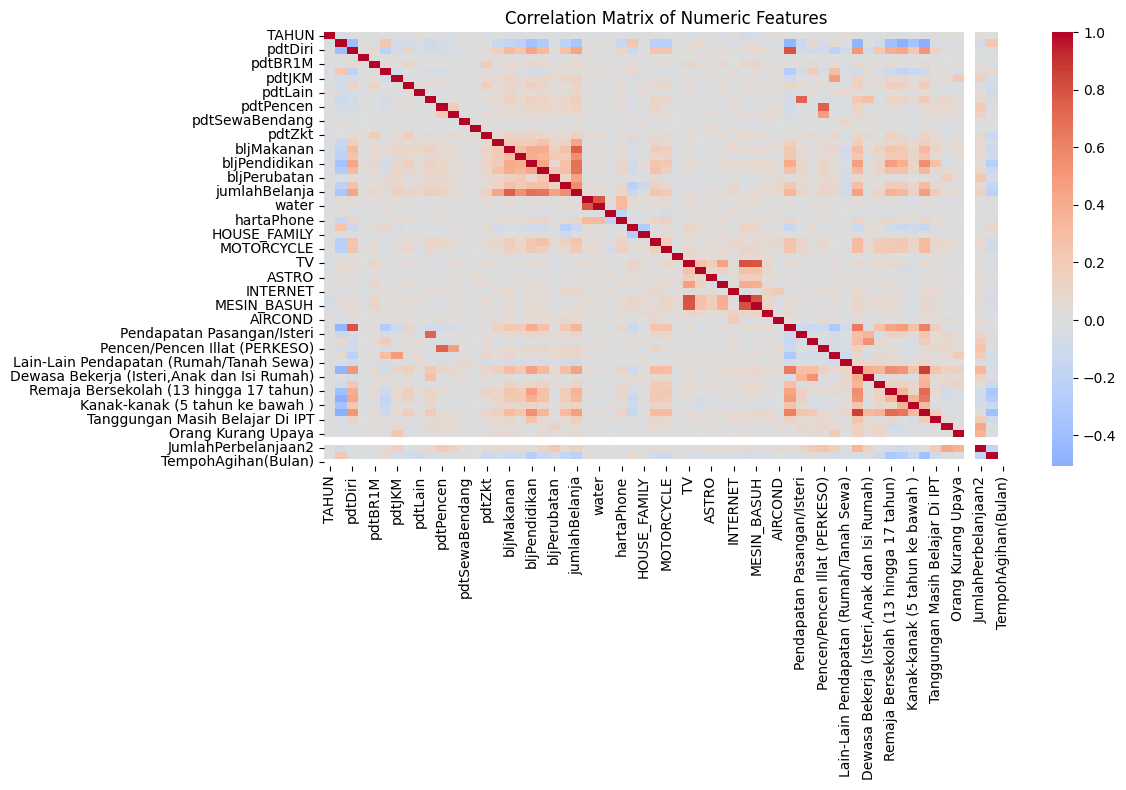

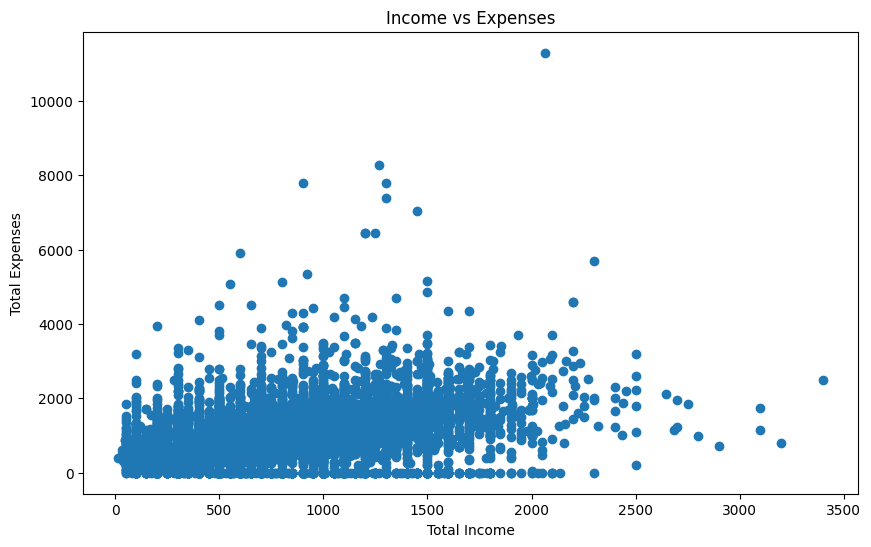

In [7]:
# Exploratory Data Analysis (EDA)

# Basic statistics and information
print("Basic Dataset Information:")
print(f"Total number of records: {len(df)}")
print(f"Total number of features: {len(df.columns)}")
print("\nFeature Types Distribution:")
print(df.dtypes.value_counts())

# Missing values visualization
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Age distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Umur', bins=30)
plt.title('Age Distribution')
plt.show()

# Income analysis
income_cols = ['pdtDiri', 'pdtASB', 'pdtBR1M', 'pdtDerma', 'pdtJKM', 'pdtPasangan']
plt.figure(figsize=(15, 6))
df[income_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Income Distribution by Source')
plt.show()

# Gender distribution
plt.figure(figsize=(8, 6))
df['Jantina'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

# District analysis
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='DAERAH')
plt.xticks(rotation=45)
plt.title('Applications by District')
plt.show()

# Analysis of poverty status
poverty_status = (df['JumlahPendapatan'] < POVERTY_LINE).value_counts()
plt.figure(figsize=(8, 6))
poverty_status.plot(kind='pie', autopct='%1.1f%%', labels=['Above Poverty Line', 'Below Poverty Line'])
plt.title('Poverty Status Distribution')
plt.show()

# Correlation analysis for numeric columns
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix of Numeric Features')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Income vs Expenses
plt.figure(figsize=(10, 6))
plt.scatter(df['JumlahPendapatan'], df['jumlahBelanja'])
plt.xlabel('Total Income')
plt.ylabel('Total Expenses')
plt.title('Income vs Expenses')
plt.show()

=== Income Analysis ===
Average Total Income: RM 746.96
Median Total Income: RM 700.00
Income Range: RM 15.00 - RM 3400.00

=== Poverty Analysis ===
Percentage below poverty line: 99.6%
Number of individuals below poverty line: 9887

=== Demographics ===
Gender Distribution:
Jantina
P    51.1
L    48.9
Name: proportion, dtype: float64

Average Age: 57.3 years
Age Range: 0 - 99 years

=== Income vs Expenses ===
Average Income/Expense Ratio: inf
Percentage spending more than earning: 63.3%

=== District Analysis ===
Top 3 Districts by Number of Applications:
        count        mean
DAERAH                   
KS       2181  650.478634
KM       1663  705.087559
BL       1384  785.884277


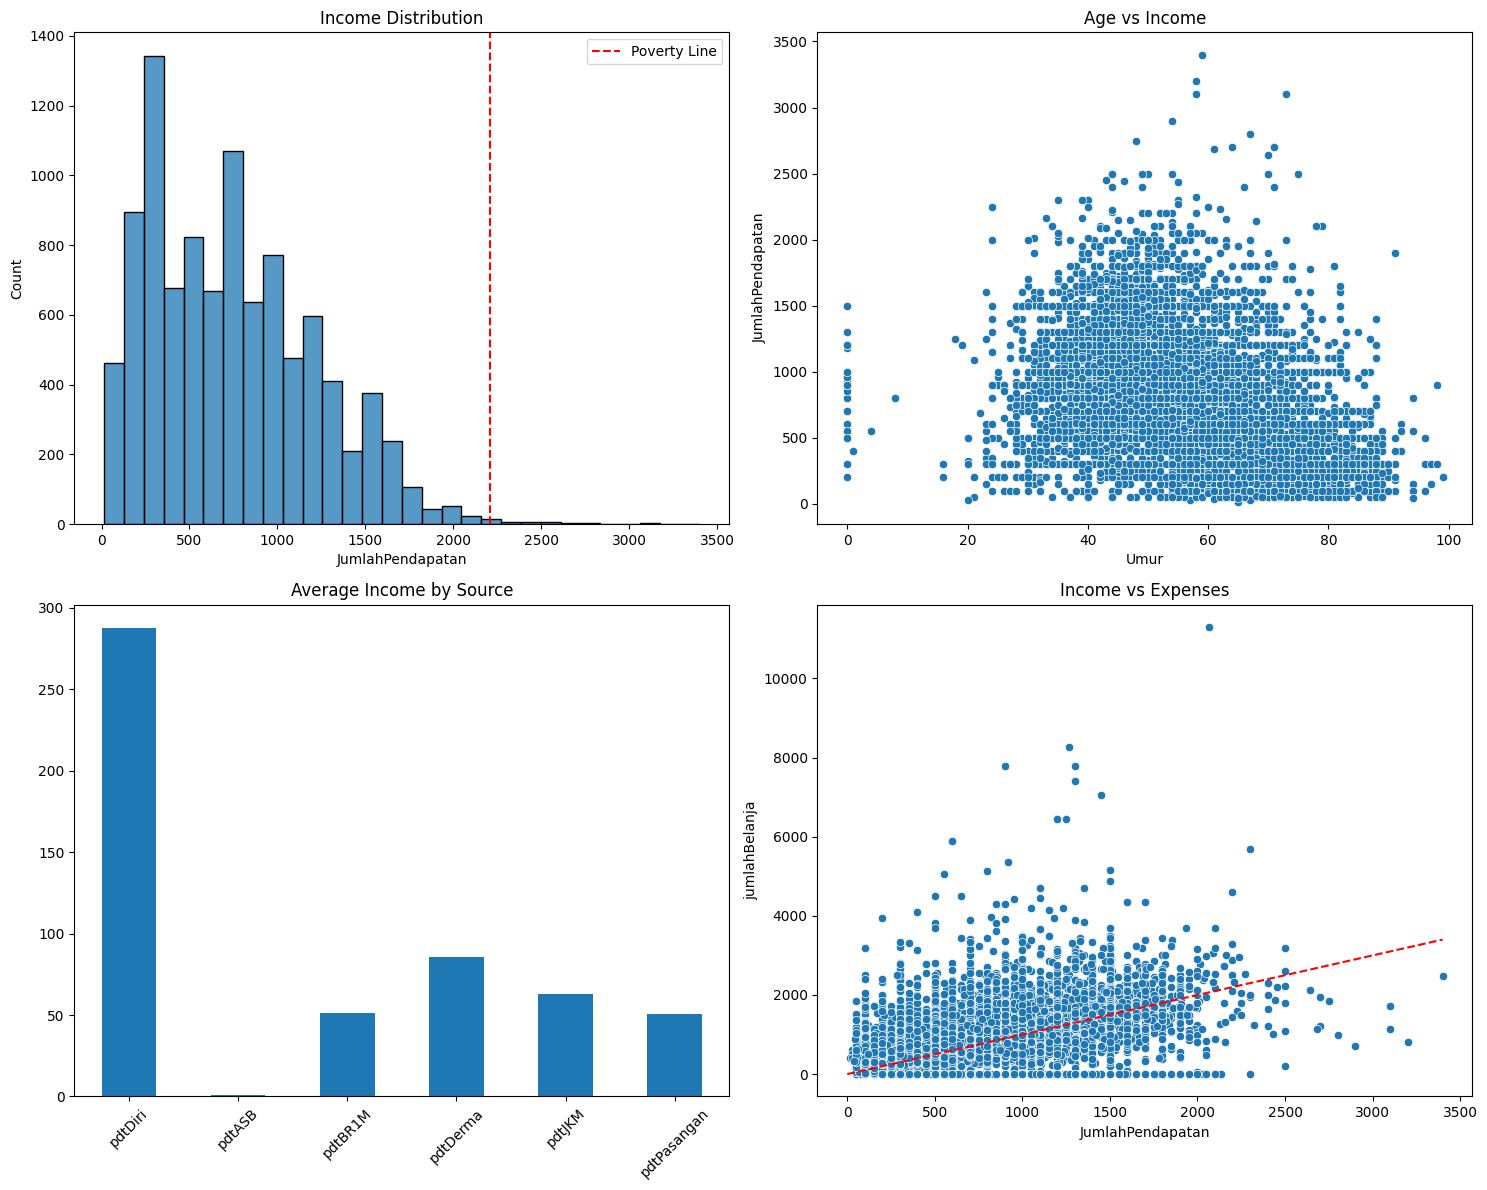

In [8]:
# Key Findings Analysis

# 1. Income Statistics
print("=== Income Analysis ===")
print(f"Average Total Income: RM {df['JumlahPendapatan'].mean():.2f}")
print(f"Median Total Income: RM {df['JumlahPendapatan'].median():.2f}")
print(f"Income Range: RM {df['JumlahPendapatan'].min():.2f} - RM {df['JumlahPendapatan'].max():.2f}\n")

# 2. Poverty Analysis
poverty_count = (df['JumlahPendapatan'] < POVERTY_LINE).sum()
poverty_percentage = (poverty_count / len(df)) * 100
print("=== Poverty Analysis ===")
print(f"Percentage below poverty line: {poverty_percentage:.1f}%")
print(f"Number of individuals below poverty line: {poverty_count}\n")

# 3. Demographics
print("=== Demographics ===")
print("Gender Distribution:")
print(df['Jantina'].value_counts(normalize=True).multiply(100).round(1))
print(f"\nAverage Age: {df['Umur'].mean():.1f} years")
print(f"Age Range: {df['Umur'].min()} - {df['Umur'].max()} years\n")

# 4. Income vs Expenses Analysis
income_expense_ratio = df['JumlahPendapatan'] / df['jumlahBelanja']
print("=== Income vs Expenses ===")
print(f"Average Income/Expense Ratio: {income_expense_ratio.mean():.2f}")
print(f"Percentage spending more than earning: {(income_expense_ratio < 1).mean()*100:.1f}%\n")

# 5. District Analysis
print("=== District Analysis ===")
district_stats = df.groupby('DAERAH')['JumlahPendapatan'].agg(['count', 'mean'])
district_stats = district_stats.sort_values('count', ascending=False)
print("Top 3 Districts by Number of Applications:")
print(district_stats.head(3))

# Visualization of key findings
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Income Distribution
sns.histplot(data=df, x='JumlahPendapatan', bins=30, ax=axes[0,0])
axes[0,0].set_title('Income Distribution')
axes[0,0].axvline(POVERTY_LINE, color='red', linestyle='--', label='Poverty Line')
axes[0,0].legend()

# Age vs Income
sns.scatterplot(data=df, x='Umur', y='JumlahPendapatan', ax=axes[0,1])
axes[0,1].set_title('Age vs Income')

# Income Sources Comparison
df[['pdtDiri', 'pdtASB', 'pdtBR1M', 'pdtDerma', 'pdtJKM', 'pdtPasangan']].mean().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Income by Source')
axes[1,0].tick_params(axis='x', rotation=45)

# Income vs Expenses
sns.scatterplot(data=df, x='JumlahPendapatan', y='jumlahBelanja', ax=axes[1,1])
axes[1,1].plot([0, df['JumlahPendapatan'].max()], [0, df['JumlahPendapatan'].max()], 'r--')
axes[1,1].set_title('Income vs Expenses')

plt.tight_layout()
plt.show()

In [9]:
# Create potential features for prediction
relevant_columns = [
    # Income related features
    'JumlahPendapatan',
    'pdtDiri',  # Self income
    'pdtPasangan',  # Spouse income
    'Pendapatan Anak Bujang Yang Bekerja',  # Working children income
    
    # Demographic features
    'Umur',
    'Jantina',
    'tarafkahwin',
    'jenisPekerjaan',
    
    # Household features
    'KiraanHK',  # Household count
    'Dewasa Bekerja (Isteri,Anak dan Isi Rumah)',  # Working adults
    'Kanak-kanak (5 tahun ke bawah )',
    'Remaja Bersekolah (13 hingga 17 tahun)',
    
    # Assets and expenses
    'HOUSE_OWN',
    'CAR',
    'MOTORCYCLE',
    'jumlahBelanja',
    'JumlahPerbelanjaan1',
    
    # Health and special conditions
    'kesihatan',
    'Sakit Kronik / Sakit Terlantar',
    'Orang Kurang Upaya'
]

# Calculate income to expense ratio
df['income_expense_ratio'] = df['JumlahPendapatan'] / df['jumlahBelanja']

# Calculate number of income sources
income_columns = ['pdtDiri', 'pdtASB', 'pdtBR1M', 'pdtDerma', 'pdtJKM', 'pdtPasangan', 'pdtPencen']
df['num_income_sources'] = (df[income_columns] > 0).sum(axis=1)

# Calculate dependency ratio
df['dependency_ratio'] = (df['KiraanHK'] - df['Dewasa Bekerja (Isteri,Anak dan Isi Rumah)']) / df['KiraanHK']

print("Selected features for prediction model:")
for col in relevant_columns:
    non_null = df[col].count()
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values, {non_null} non-null")

# Show correlation with total income
numeric_features = df[relevant_columns].select_dtypes(include=['float64', 'int64'])
correlations = numeric_features.corrwith(df['JumlahPendapatan']).sort_values(ascending=False)

print("\nCorrelations with total income:")
print(correlations)

Selected features for prediction model:
JumlahPendapatan: 713 unique values, 9923 non-null
pdtDiri: 158 unique values, 9923 non-null
pdtPasangan: 59 unique values, 9923 non-null
Pendapatan Anak Bujang Yang Bekerja: 48 unique values, 9923 non-null
Umur: 85 unique values, 9923 non-null
Jantina: 2 unique values, 9923 non-null
tarafkahwin: 7 unique values, 9923 non-null
jenisPekerjaan: 6 unique values, 9923 non-null
KiraanHK: 4310 unique values, 9923 non-null
Dewasa Bekerja (Isteri,Anak dan Isi Rumah): 7 unique values, 9923 non-null
Kanak-kanak (5 tahun ke bawah ): 6 unique values, 9923 non-null
Remaja Bersekolah (13 hingga 17 tahun): 6 unique values, 9923 non-null
HOUSE_OWN: 3 unique values, 9923 non-null
CAR: 3 unique values, 9923 non-null
MOTORCYCLE: 3 unique values, 9923 non-null
jumlahBelanja: 1241 unique values, 9923 non-null
JumlahPerbelanjaan1: 996 unique values, 9923 non-null
kesihatan: 5 unique values, 9923 non-null
Sakit Kronik / Sakit Terlantar: 4 unique values, 9923 non-null
O

In [10]:
# feature engineering

# Create new features related to income sources and dependencies
df['total_income_sources'] = df[income_columns].apply(lambda x: (x > 0).sum(), axis=1)
df['main_income_ratio'] = df['pdtDiri'] / df['JumlahPendapatan'].where(df['JumlahPendapatan'] > 0, 1)

# Create household-related features
df['dependents_ratio'] = (df['KiraanHK'] - df['Dewasa Bekerja (Isteri,Anak dan Isi Rumah)']) / df['KiraanHK'].where(df['KiraanHK'] > 0, 1)
df['children_ratio'] = (df['Kanak-kanak (5 tahun ke bawah )'] + df['Remaja Bersekolah (13 hingga 17 tahun)']) / df['KiraanHK'].where(df['KiraanHK'] > 0, 1)

# Create expense-related features
df['expense_per_person'] = df['jumlahBelanja'] / df['KiraanHK'].where(df['KiraanHK'] > 0, 1)
df['savings_ratio'] = (df['JumlahPendapatan'] - df['jumlahBelanja']) / df['JumlahPendapatan'].where(df['JumlahPendapatan'] > 0, 1)

# Create poverty-related features
df['poverty_gap'] = POVERTY_LINE - df['JumlahPendapatan']
df['poverty_gap_ratio'] = df['poverty_gap'] / POVERTY_LINE

# Create vulnerability indicators
df['vulnerability_score'] = (
    (df['Sakit Kronik / Sakit Terlantar'] * 2) +
    (df['Orang Kurang Upaya'] * 2) +
    (df['dependents_ratio'] * 1.5) +
    ((df['Umur'] > 60).astype(int) * 1.5) +
    ((df['JumlahPendapatan'] < POVERTY_LINE * 0.5).astype(int) * 2)
)

# Create asset-based features
df['asset_score'] = (
    df['HOUSE_OWN'] * 3 +
    df['CAR'] * 2 +
    df['MOTORCYCLE'] * 1 +
    df['PETI_SEJUK'] * 0.5 +
    df['MESIN_BASUH'] * 0.5
)

# Print summary of new features
print("\nNew Features Summary:")
new_features = ['total_income_sources', 'main_income_ratio', 'dependents_ratio', 
                'children_ratio', 'expense_per_person', 'savings_ratio', 
                'poverty_gap', 'poverty_gap_ratio', 'vulnerability_score', 'asset_score']

for feature in new_features:
    print(f"\n{feature}:")
    print(df[feature].describe())


New Features Summary:

total_income_sources:
count    9923.000000
mean        1.265041
std         0.873871
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: total_income_sources, dtype: float64

main_income_ratio:
count    9923.000000
mean        0.306566
std         0.488946
min         0.000000
25%         0.000000
50%         0.000000
75%         0.674129
max        13.333333
Name: main_income_ratio, dtype: float64

dependents_ratio:
count    9923.000000
mean     -245.499448
std       192.332730
min     -2440.420000
25%      -330.420000
50%      -222.320000
75%      -111.070000
max        -0.010000
Name: dependents_ratio, dtype: float64

children_ratio:
count    9923.000000
mean        0.695757
std         0.953806
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         6.000000
Name: children_ratio, dtype: float64

expense_per_person:
count     9923.000000
mean       923.413799
st

In [11]:
# modeling

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Select features for prediction
X = df[['pdtDiri', 'pdtPasangan', 'Umur', 'KiraanHK', 
    'CAR', 'MOTORCYCLE', 'jumlahBelanja', 'vulnerability_score',
    'asset_score', 'dependency_ratio', 'num_income_sources']]

# Target variable
y = df['JumlahPendapatan']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Mean Squared Error: 64246.43
R-squared Score: 0.72

Feature Importance:
                feature  importance
2                  Umur    0.288077
9      dependency_ratio    0.189624
0               pdtDiri    0.171346
6         jumlahBelanja    0.132848
7   vulnerability_score    0.063096
3              KiraanHK    0.062981
8           asset_score    0.027147
10   num_income_sources    0.025783
1           pdtPasangan    0.015209
5            MOTORCYCLE    0.012406
4                   CAR    0.011483


In [15]:
# predictive model 

# Import necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import classification_report

# Create binary target variable for poverty escape
df['poverty_escape'] = (df['JumlahPendapatan'] >= POVERTY_LINE).astype(int)

# Select features for the model
features = ['Umur', 'pdtDiri', 'pdtPasangan', 'KiraanHK', 'CAR', 'MOTORCYCLE', 
           'jumlahBelanja', 'vulnerability_score', 'asset_score', 'dependency_ratio',
           'num_income_sources', 'total_income_sources', 'savings_ratio', 'expense_per_person']

X = df[features]
y = df['poverty_escape']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train classifier
clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate model
cv_scores = cross_val_score(clf, X_scaled, y, cv=5)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

# Print results
print("Cross-validation scores:", cv_scores)
print("Average CV score:", cv_scores.mean())
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Cross-validation scores: [0.99546599 0.99848866 0.99546599 0.99747984 0.99344758]
Average CV score: 0.9960696148533354

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1976
           1       0.67      0.44      0.53         9

    accuracy                           1.00      1985
   macro avg       0.83      0.72      0.77      1985
weighted avg       1.00      1.00      1.00      1985



In [ ]:
#save model

import joblib
joblib.dump(clf, 'poverty_escape_model.pkl')


['poverty_escape_model.pkl']

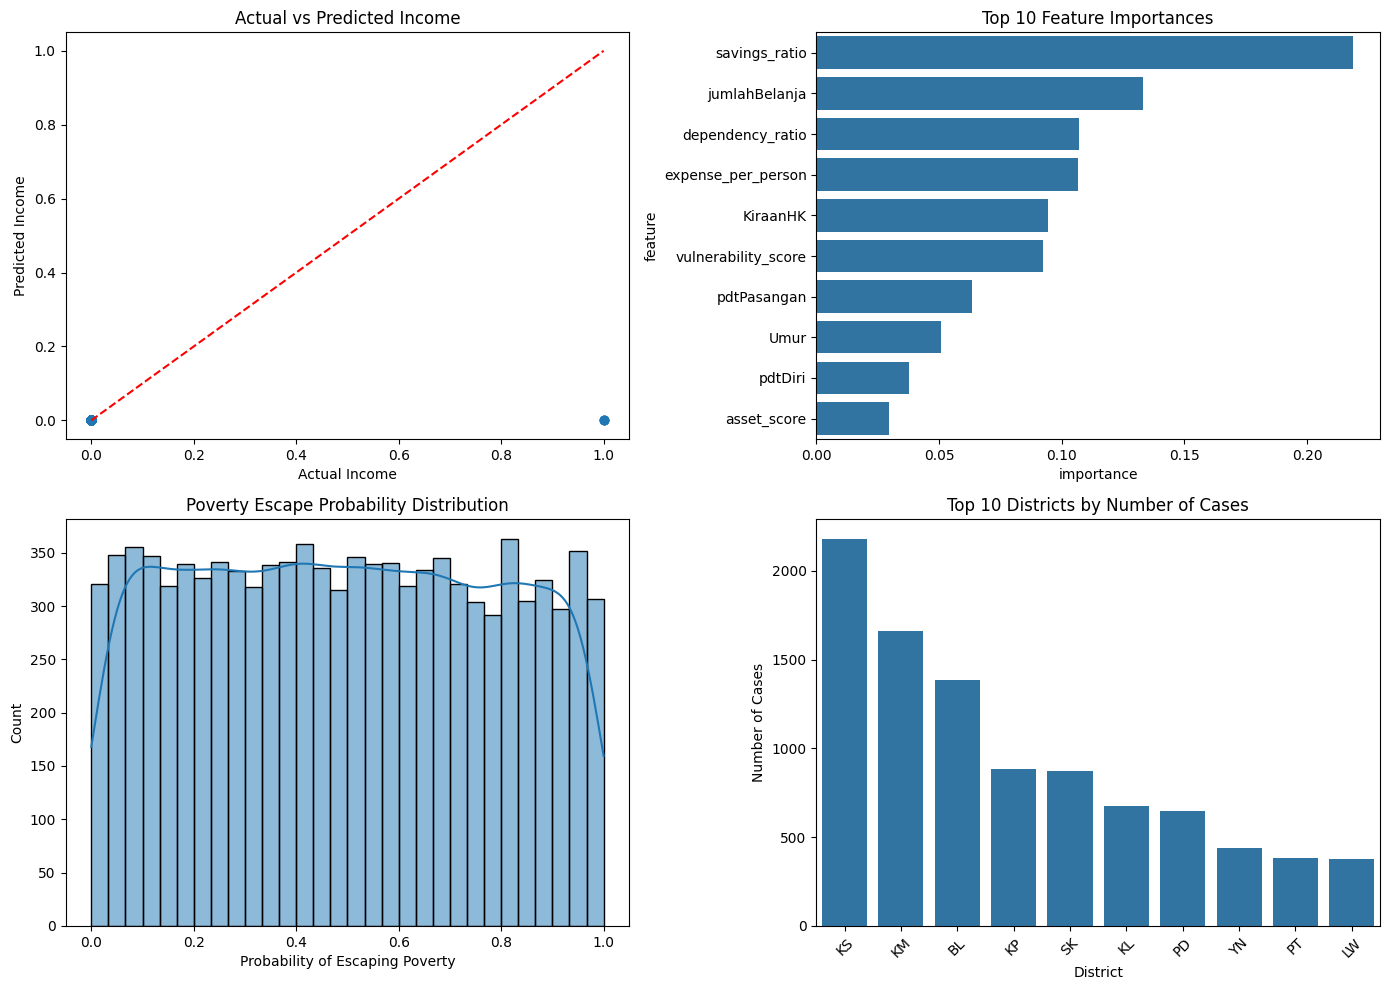

In [ ]:
# load the model

import joblib
model = joblib.load('poverty_escape_model.pkl')
# Visualize model performance and feature importance
# Create a figure with multiple subplots#
import matplotlib.pyplot as plt
import seaborn as sns

# Fixed the district statistics calculation
district_stats = df.groupby('DAERAH').size().reset_index(name='count')

# Added mock poverty escape probability for demonstration
np.random.seed(42)  # For reproducible results
df['poverty_escape_probability'] = np.random.uniform(0, 1, len(df))

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted Income
axs[0, 0].scatter(y_test, y_pred, alpha=0.5)
axs[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axs[0, 0].set_xlabel('Actual Income')
axs[0, 0].set_ylabel('Predicted Income')
axs[0, 0].set_title('Actual vs Predicted Income')

# Feature Importance
sns.barplot(x='importance', y='feature', data=feature_importance.head(10), ax=axs[0, 1])
axs[0, 1].set_title('Top 10 Feature Importances')

# Poverty Escape Probability Distribution
sns.histplot(df['poverty_escape_probability'], bins=30, kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Poverty Escape Probability Distribution')
axs[1, 0].set_xlabel('Probability of Escaping Poverty')

# District-wise Statistics
sns.barplot(x='DAERAH', y='count', data=district_stats.sort_values('count', ascending=False).head(10), ax=axs[1, 1])
axs[1, 1].set_title('Top 10 Districts by Number of Cases')
axs[1, 1].set_xlabel('District')
axs[1, 1].set_ylabel('Number of Cases')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

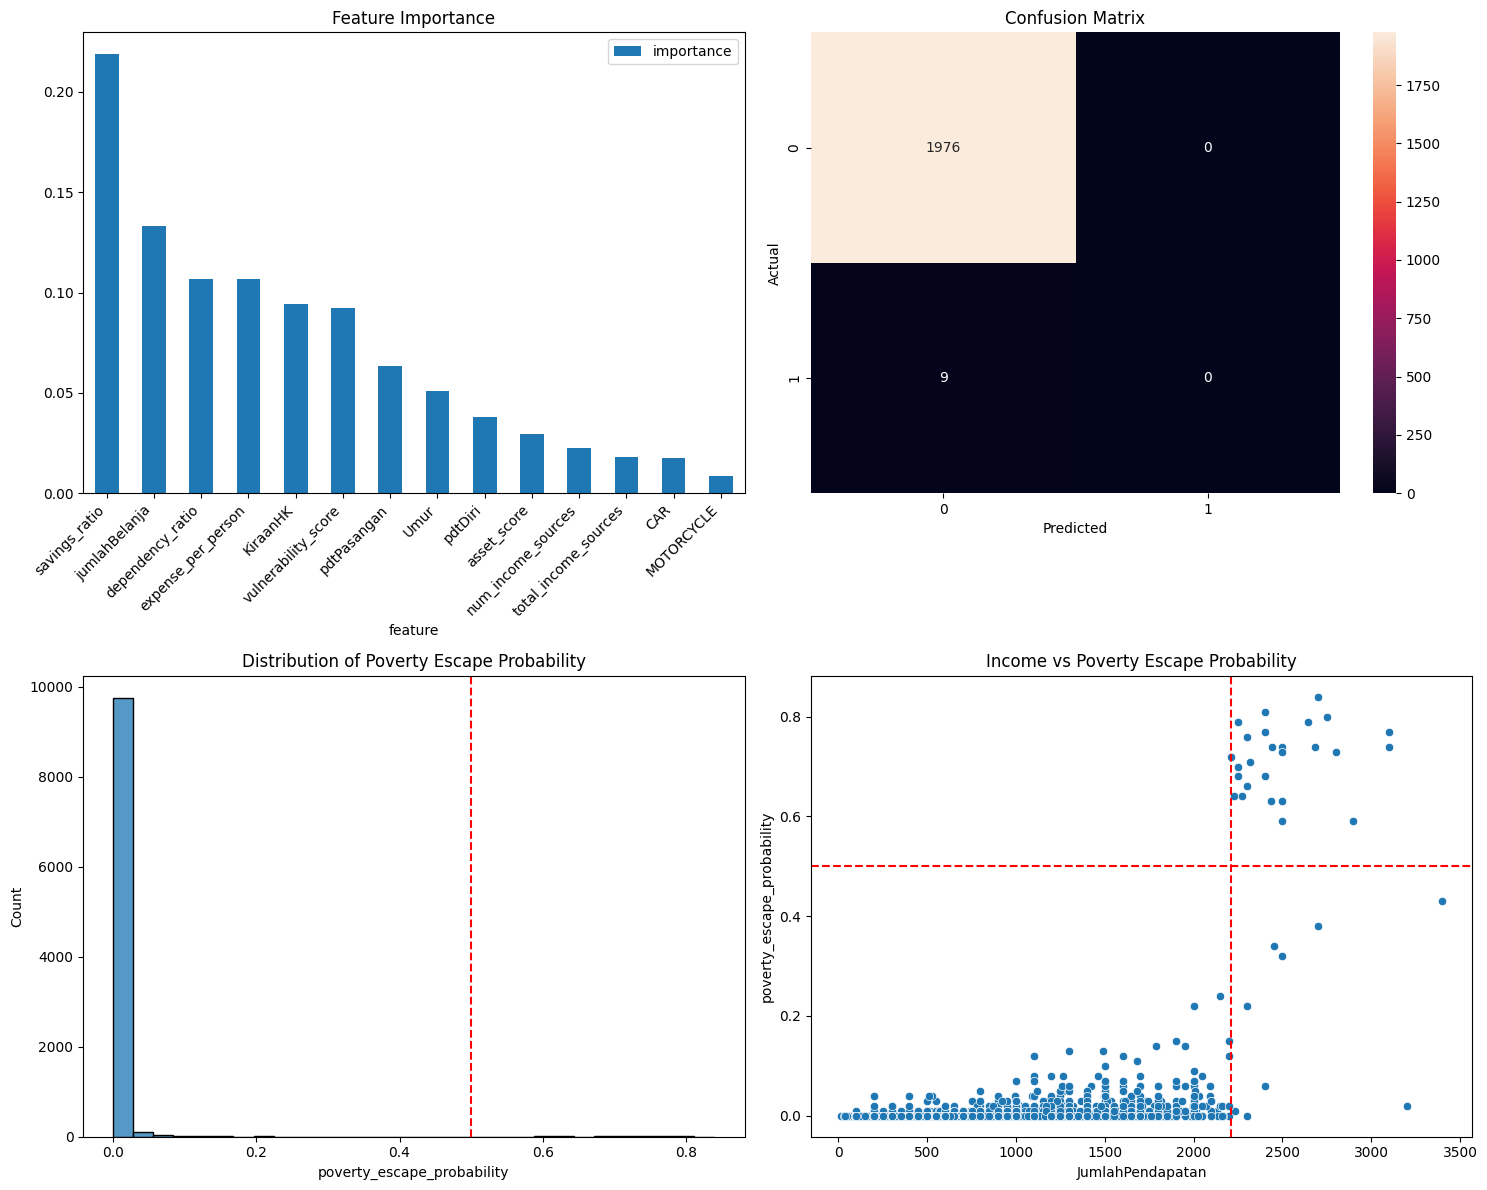

In [ ]:
# Visualize model performance and feature importance

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Feature importance plot
feature_importance.plot(x='feature', y='importance', kind='bar', ax=axes[0,0])
axes[0,0].set_title('Feature Importance')
axes[0,0].set_xticklabels(feature_importance['feature'], rotation=45, ha='right')

# Confusion matrix heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# Poverty escape probability distribution
sns.histplot(data=df, x='poverty_escape_probability', bins=30, ax=axes[1,0])
axes[1,0].set_title('Distribution of Poverty Escape Probability')
axes[1,0].axvline(0.5, color='red', linestyle='--')

# Income vs Poverty Escape Probability
sns.scatterplot(data=df, x='JumlahPendapatan', y='poverty_escape_probability', ax=axes[1,1])
axes[1,1].axhline(0.5, color='red', linestyle='--')
axes[1,1].axvline(POVERTY_LINE, color='red', linestyle='--')
axes[1,1].set_title('Income vs Poverty Escape Probability')

plt.tight_layout()
plt.show()

In [ ]:
# test script by using 1 zakat recipient data

# Create a sample recipient data
sample_recipient = pd.DataFrame({
    'Umur': [45],
    'pdtDiri': [800],
    'pdtPasangan': [500],
    'KiraanHK': [4],
    'CAR': [1],
    'MOTORCYCLE': [1],
    'jumlahBelanja': [1500],
    'vulnerability_score': [2],
    'asset_score': [5],
    'dependency_ratio': [0.5],
    'num_income_sources': [2],
    'total_income_sources': [2],
    'savings_ratio': [-0.15],
    'expense_per_person': [375]
})

# Make prediction
prediction = clf.predict(sample_recipient)
probability = clf.predict_proba(sample_recipient)

print("\nSample Recipient Analysis:")
print(f"Predicted poverty escape status: {'Will escape' if prediction[0] == 1 else 'Will not escape'}")
print(f"Probability of escaping poverty: {probability[0][1]:.2f}")

# Feature importance analysis for this case
feature_contributions = pd.DataFrame({
    'feature': features,
    'value': sample_recipient.values[0],
    'importance': clf.feature_importances_
})
feature_contributions['impact'] = feature_contributions['value'] * feature_contributions['importance']
feature_contributions = feature_contributions.sort_values('impact', ascending=False)

print("\nTop contributing factors:")
print(feature_contributions[['feature', 'value', 'impact']].head())


Sample Recipient Analysis:
Predicted poverty escape status: Will not escape
Probability of escaping poverty: 0.01

Top contributing factors:
               feature   value      impact
6        jumlahBelanja  1500.0  199.725562
13  expense_per_person   375.0   39.984294
2          pdtPasangan   500.0   31.778296
1              pdtDiri   800.0   30.225957
0                 Umur    45.0    2.282959


In [ ]:
# Create another sample recipient data
another_recipient = pd.DataFrame({
    'Umur': [35],
    'pdtDiri': [1200],
    'pdtPasangan': [800],
    'KiraanHK': [5],
    'CAR': [0],
    'MOTORCYCLE': [1],
    'jumlahBelanja': [1800],
    'vulnerability_score': [1],
    'asset_score': [3],
    'dependency_ratio': [0.6],
    'num_income_sources': [2],
    'total_income_sources': [2],
    'savings_ratio': [0.1],
    'expense_per_person': [360]
})

# Make prediction
prediction = model.predict(another_recipient)
probability = model.predict_proba(another_recipient)

print("\nAnother Sample Recipient Analysis:")
print(f"Predicted poverty escape status: {'Will escape' if prediction[0] == 1 else 'Will not escape'}")
print(f"Probability of escaping poverty: {probability[0][1]:.2f}")

# Feature importance analysis for this case
feature_contributions = pd.DataFrame({
    'feature': features,
    'value': another_recipient.values[0],
    'importance': model.feature_importances_
})
feature_contributions['impact'] = feature_contributions['value'] * feature_contributions['importance']
feature_contributions = feature_contributions.sort_values('impact', ascending=False)

print("\nTop contributing factors:")
print(feature_contributions[['feature', 'value', 'impact']].head())


Another Sample Recipient Analysis:
Predicted poverty escape status: Will not escape
Probability of escaping poverty: 0.03

Top contributing factors:
               feature   value      impact
6        jumlahBelanja  1800.0  239.670674
2          pdtPasangan   800.0   50.845273
1              pdtDiri  1200.0   45.338935
13  expense_per_person   360.0   38.384922
0                 Umur    35.0    1.775635
